### Docker Commands

# Docker pull docker/getting-started


Using default tag: latest
latest: Pulling from docker/getting-started

4f7e34c2de10: Download complete
b6334b6ace34: Download complete
f1d1c9928c82: Download complete
9b6f639ec6ea: Download complete
c158987b0551: Download complete
ee68d3549ec8: Download complete
1e35f6679fab: Download complete
33e0cbbb4673: Download complete
cb9626c74200: Download complete

1. Digest: sha256:d79336f4812b6547a53e735480dde67f8f8f7071b414fbd9297609ffb989abc1
2. Status: Downloaded newer image for docker/getting-started:latest
3. docker.io/docker/getting-started:latest

## Command Structure

**`docker run hello-world`**
- `hello-world` is a test image that:
- Prints a message
- Exits immediately
- Doesn't run a web server
**` docker run -d p 80:80 docker/getting-started`**

**`docker run`**
- Executes a new container from an image
- Example: `docker run nginx` creates and starts an nginx container

**`-d`** (detached mode)
- Runs container in background, doesn't block your terminal
- Example: Without `-d`, logs would stream to your console; with it, you get control back immediately

**`-p 80:80`** (port mapping)
- Maps ports between host and container: `HOST_PORT:CONTAINER_PORT`
- Routes traffic from your machine's port 80 to the container's port 80
- Example: `-p 8080:80` would let you access the container at `localhost:8080` even though it runs on port 80 internally

**`docker/getting-started`**
- The Docker image name to run
- Format is `repository/image:tag` (tag defaults to `latest` if omitted)
- Example: `nginx:alpine` or `ubuntu:22.04`

## Complete Example

After running this command, you could visit `http://localhost` in your browser to see the Docker tutorial app.

## Other Common Variations

```bash
docker run -d -p 3000:80 --name my-app nginx
# Adds a custom container name

docker run -d -p 8080:80 -v /my/files:/usr/share/nginx/html nginx
# Adds volume mounting for persistent data
```

 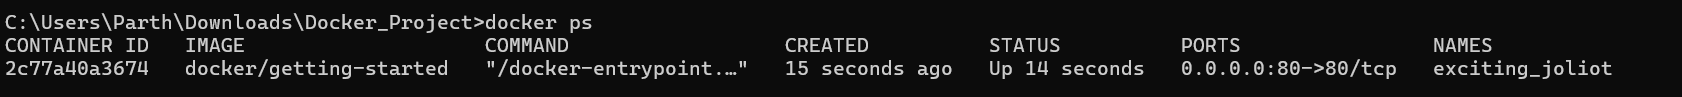
 **why** and **when** you need `docker ps`:

## Why `docker ps` Exists

**Problem it solves**: Once you run containers with `-d` (detached mode), they disappear into the background. You need a way to see what's actually running.

**Analogy**: Like Task Manager (Windows) or `top` (Linux) - you need to see what processes are active.

## Common Real-World Use Cases

### 1. **Checking if your container started successfully**
```bash
docker run -d -p 80:80 nginx
docker ps    # Did it actually start? Is it still running?
```

### 2. **Getting the Container ID for other commands**
```bash
docker ps    # Find the ID
# CONTAINER ID   IMAGE   ...
# 2c77a40a3674   nginx   ...

docker logs 2c77         # View logs
docker exec -it 2c77 bash    # Enter the container
docker stop 2c77         # Stop it
```

### 3. **Checking port mappings**
"Wait, which port did I expose that database on again?"
```bash
docker ps
# PORTS
# 0.0.0.0:3306->3306/tcp   # Ah, MySQL is on 3306
# 0.0.0.0:8080->80/tcp     # Web app is on 8080
```

### 4. **Troubleshooting crashes**
```bash
docker ps        # Container not listed? It crashed
docker ps -a     # Shows stopped containers too
# STATUS
# Exited (137) 2 minutes ago   # Killed by system
# Exited (0) 5 seconds ago     # Stopped normally
```

### 5. **Managing multiple containers**
When running a full application stack:
```bash
docker ps
# CONTAINER ID   IMAGE       PORTS                    NAMES
# abc123         postgres    0.0.0.0:5432->5432/tcp   my-database
# def456         redis       0.0.0.0:6379->6379/tcp   my-cache
# ghi789         node:16     0.0.0.0:3000->3000/tcp   my-api
```


**Bottom line**: You use `docker ps` constantly when working with Docker - it's your "what's happening?" command. Without it, you'd be flying blind with background containers.


## Column Breakdown

**`CONTAINER ID`**: `2c77a40a3674`
- Unique identifier for this container instance
- You can use this (or just the first few characters like `2c77`) in commands
- Example: `docker stop 2c77` or `docker logs 2c77a40a3674`

**`IMAGE`**: `docker/getting-started`
- The image this container was created from
- Same image can spawn multiple containers with different IDs

**`COMMAND`**: `/docker-entrypoint.…`
- The command running inside the container (truncated here)
- This is what keeps the container alive

**`CREATED`**: `15 seconds ago`
- How long ago the container was created
- Self-explanatory timestamp

**`STATUS`**: `Up 14 seconds`
- Current state and uptime
- Other states: `Exited`, `Restarting`, `Paused`
- Example: `Exited (0) 2 minutes ago` means it stopped successfully

**`PORTS`**: `0.0.0.0:80->80/tcp`
- Port mappings: `HOST_IP:HOST_PORT->CONTAINER_PORT/PROTOCOL`
- `0.0.0.0` means accessible from any network interface
- Example: `0.0.0.0:8080->80/tcp` would mean access via port 8080

**`NAMES`**: `exciting_joliot`
- Auto-generated friendly name (Docker picks random adjective + scientist)
- You can specify your own with `--name`: `docker run -d --name my-tutorial -p 80:80 docker/getting-started`
- Use in commands: `docker stop exciting_joliot`

## Useful Related Commands

```bash
docker ps -a              # Show all containers (including stopped)
docker logs exciting_joliot   # View container logs
docker stop exciting_joliot   # Stop the container
docker rm exciting_joliot     # Remove the container
```

Here's how to use `docker stop`:

## Basic Usage

```bash
docker stop 2c77a40a3674    # Full container ID
docker stop 2c77            # Short form (first few chars)
docker stop exciting_joliot # Container name
```

All three methods work for your container!

## What Happens When You Stop

```bash
docker stop 2c77
# Container gracefully shuts down (gets 10 seconds to clean up)

docker ps
# Container disappears from running list

docker ps -a
# STATUS
# Exited (0) 10 seconds ago   # Now shows as stopped
```

## Comparison: Stop vs Kill vs Remove

```bash
# Graceful shutdown (recommended)
docker stop 2c77            # Sends SIGTERM, waits, then SIGKILL

# Immediate termination (forceful)
docker kill 2c77            # Sends SIGKILL immediately

# Delete container completely
docker rm 2c77              # Must stop first (or use -f)
docker rm -f 2c77           # Force remove even if running
```

## Common Workflows

**Stop and restart:**
```bash
docker stop exciting_joliot
docker start exciting_joliot    # Restarts the same container
docker ps                       # Back in the list
```

**Stop and remove:**
```bash
docker stop 2c77
docker rm 2c77                  # Removes container permanently
docker ps -a                    # Gone completely
```

**Stop all running containers:**
```bash
docker stop $(docker ps -q)     # Stops everything
```

## Quick Reference

| Command | What It Does |
|---------|-------------|
| `docker stop` | Graceful shutdown |
| `docker kill` | Force kill immediately |
| `docker start` | Restart a stopped container |
| `docker restart` | Stop then start |
| `docker rm` | Delete container |
| `docker rm -f` | Force delete (even if running) |

**Tip**: You typically use `docker stop` when you're done testing or want to free up the port!

Great Dockerfile! Here's what each line does:

## Line-by-Line Breakdown

**`FROM python:3.8-alpine`**
- **Base image**: Starts with Python 3.8 on Alpine Linux
- `alpine` = Lightweight Linux distribution (~5MB vs ~900MB for standard)
- Example: Like starting with a pre-installed Python environment
- Other options: `python:3.8`, `python:3.11-slim`, `python:3.12-alpine`

**`COPY . /app`**
- **Copies files** from your current directory (`.`) to `/app` inside the container
- `.` = Everything in the folder with your Dockerfile
- `/app` = Destination folder in the container
- Example: Copies `app.py`, `requirements.txt`, etc. into the container

**`WORKDIR /app`**
- **Sets working directory** to `/app`
- All subsequent commands run from this directory
- Like doing `cd /app` in the terminal
- Example: When `CMD python app.py` runs, it looks for `app.py` in `/app`

**`RUN pip install -r requirements.txt`**
- **Executes command** during image build (not at runtime)
- Installs Python dependencies from `requirements.txt`
- Runs only once when building the image
- Example: Installs Flask, requests, etc.

**`CMD python app.py`**
- **Default command** when container starts
- Runs your Flask application
- Executes at **runtime** (every time you `docker run`)
- Example: Starts the web server

## Visual Flow

```
Build Time:
FROM python:3.8-alpine     → Downloads base image
COPY . /app                → Copies your files
WORKDIR /app               → Sets directory
RUN pip install ...        → Installs dependencies

Runtime (docker run):
CMD python app.py          → Starts your Flask app
```

## Required Files

Your project structure should look like:

```
my-flask-app/
├── Dockerfile
├── app.py
└── requirements.txt
```

**requirements.txt:**
```txt
flask
```

## How to Build and Run

```bash
# Build the Docker image
docker build -t my-flask-app .

# Run the container
docker run -d -p 5000:5000 my-flask-app

# Access at:
# http://localhost:5000
```

## ⚠️ Issue with Your Flask App

Your `app.py` needs to listen on `0.0.0.0` (not just `127.0.0.1`) to be accessible outside the container:

```python
if __name__ == "__main__":
    app.run(debug=True, host='0.0.0.0', port=5000)
    #              ↑ Listen on all interfaces
```

Without `host='0.0.0.0'`, the Flask app only listens inside the container and won't respond to requests from your browser!

## Complete Working Example

**Dockerfile:**
```dockerfile
FROM python:3.8-alpine
COPY . /app
WORKDIR /app
RUN pip install -r requirements.txt
CMD python app.py
```


**Build & Run:**
```bash
docker build -t my-flask-app .
docker run -d -p 5000:5000 my-flask-app
# Visit http://localhost:5000
```

**Key Points**: 
- `RUN` executes during **build** (installs dependencies)
- `CMD` executes during **run** (starts your app)
- Always use `host='0.0.0.0'` in Flask for Docker!
## note: you can't access the container address. 


You can **rename** (tag) a Docker image using the `docker tag` command:

## Rename an Existing Image

```bash
docker tag old_name new_name
```

### Example

```bash
# Your current image
docker tag my_flask_app user_name/flask-web-app


#### Push docker image to docker HUB

# docker push user_name/image_name: latest
```bash
docker push yny878/flask_app:latest
```